# Input Data Analysis - Baltalimani Outpatient Clinic

This notebook produces the **Section 1.3 Input Data Analysis** content for the IE 304 project report.

Structure:

1. Raw data profile
2. Cleaning audit (via `data_prep.load_and_clean`)
3. Arrival analysis (day-of-week, hour-of-day, inter-arrival times)
4. Routing probabilities per department
5. Service time distributions (histograms + ECDFs)
6. Distribution fitting with goodness-of-fit (K-S + Chi-square)
7. Emit `config.yml`
8. QA sanity check (sample from fitted distributions, compare moments)

All cleaning logic lives in [`data_prep.py`](data_prep.py); this notebook is pure orchestration and visualisation so that the report text can cite concrete numbers without re-running the whole pipeline.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from scipy import stats

import data_prep as dp

DATA_PATH = "Baltalimani_Data_2025.xlsx"
DEPT_MAPPING_PATH = "Baltalimani_Data_2025.csv"
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

APPOINTMENT_SCHEDULES = {
    "schedule_1": {
        "description": "Every 6 min, 08:00-12:00 and 13:00-16:00",
        "windows": [
            {"start": "08:00", "end": "12:00", "interval_minutes": 6},
            {"start": "13:00", "end": "16:00", "interval_minutes": 6},
        ],
    },
    "schedule_2": {
        "description": "Mixed intervals by block",
        "windows": [
            {"start": "08:00", "end": "10:00", "interval_minutes": 6},
            {"start": "10:00", "end": "12:00", "interval_minutes": 10},
            {"start": "13:00", "end": "15:00", "interval_minutes": 8},
            {"start": "15:00", "end": "16:00", "interval_minutes": 10},
        ],
    },
    "schedule_3": {
        "description": "Morning only: 6 min then 8 min",
        "windows": [
            {"start": "08:00", "end": "10:00", "interval_minutes": 6},
            {"start": "10:00", "end": "12:00", "interval_minutes": 8},
        ],
    },
}

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

RNG = np.random.default_rng(20260423)

## 1. Raw data profile

Before cleaning anything we document the shape of the workbook as it landed on disk. Every number below goes into the *Data Description* subsection of the report.

In [2]:
raw = dp.load_raw(DATA_PATH)
print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.dtypes.to_frame("dtype")

Raw shape: 12,263 rows x 13 columns


,dtype
HASTA_ADI_SOYADI,str
TC_KIMLIK_NO,str
CINSIYET,str
DOKTOR_ADI,str
DOGUM_YILI,int64
GIRIS_TARIHI,datetime64[us]
RANDEVU_BASLAMA_SAATI,datetime64[us]
MUAYENE_KABUL_ZAMANI,datetime64[us]
CAGRILMA_ZAMANI,datetime64[us]
TETKIK_ISTEK_SAATI,datetime64[us]


In [3]:
missing = raw.isna().sum().to_frame("missing")
missing["missing_pct"] = (missing["missing"] / len(raw) * 100).round(2)
missing.sort_values("missing", ascending=False)

,missing,missing_pct
RONTGEN_ODA_NO,5087,41.48
CEKIM_ZAMANI,5064,41.29
TETKIK_ISTEK_SAATI,4935,40.24
CAGRILMA_ZAMANI,3466,28.26
MUAYENE_SONLANDIRMA_ZAMANI,1095,8.93
MUAYENE_KABUL_ZAMANI,586,4.78
DOGUM_YILI,0,0.00
CINSIYET,0,0.00
TC_KIMLIK_NO,0,0.00
HASTA_ADI_SOYADI,0,0.00


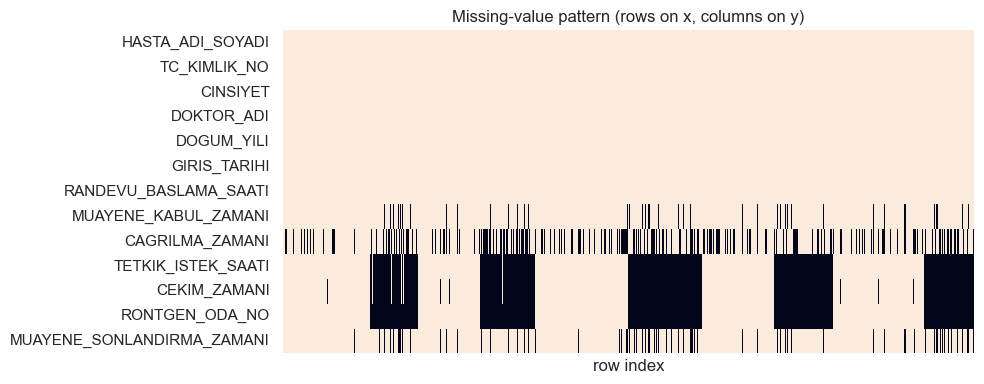

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(raw.isna().T, cbar=False, ax=ax, cmap="rocket_r")
ax.set_title("Missing-value pattern (rows on x, columns on y)")
ax.set_xlabel("row index")
ax.set_xticks([])
fig.tight_layout()
fig.savefig(OUT_DIR / "missing_value_heatmap.png", dpi=150)
plt.show()

## 2. Cleaning audit

The cleaning pipeline runs in 10 deterministic steps. The audit table below reports how many rows each step consumed or masked; copy it verbatim into the report appendix.

In [5]:
doctor_to_department = dp.load_doctor_department_mapping(DEPT_MAPPING_PATH)
all_departments = {d for specs in doctor_to_department.values() for d in specs}
multi_specialty_doctors = {d: specs for d, specs in doctor_to_department.items() if len(specs) > 1}

print(f"Loaded mapping: {len(doctor_to_department)} doctors -> {len(all_departments)} distinct specialties")
print(f"Doctors with >1 specialty: {len(multi_specialty_doctors)}")
if multi_specialty_doctors:
    for doc, specs in sorted(multi_specialty_doctors.items()):
        print(f"  {doc}: {specs}")

df, log = dp.load_and_clean(DATA_PATH, doctor_to_department=doctor_to_department)

unmapped = sorted(set(df["DOKTOR_ADI"].unique()) - set(doctor_to_department))
if unmapped:
    print(f"\nWARNING: {len(unmapped)} doctors in data but not in the mapping CSV: {unmapped}")
else:
    print("\nAll doctors in the data are present in the mapping CSV.")

audit = log.to_frame()
audit.to_csv(OUT_DIR / "cleaning_audit.csv", index=False)

audit_df = pd.DataFrame(audit)
pd.set_option('display.max_colwidth', None)
audit_df.head(20)

Loaded mapping: 32 doctors -> 9 distinct specialties
Doctors with >1 specialty: 12
  AHMET FIRAT BERKAY: ['ShoulderSports', 'KneeMeniscus']
  AHMET KOCABIYIK: ['AdultHipKnee', 'BoneDeformity']
  BARIŞ ÇAYPINAR: ['AdultHipKnee', 'Spine']
  BARIŞ ÖZKUL: ['AdultHipKnee', 'BoneDeformity']
  DENİZ KARGIN: ['AdultHipKnee', 'Spine']
  GÖKHAN PEHLİVANOĞLU: ['ShoulderSports', 'KneeMeniscus']
  KADİR İLKER YILDIZ: ['ShoulderSports', 'KneeMeniscus']
  MEHMET ÖZBEY BÜYÜKKUŞCU: ['ShoulderSports', 'KneeMeniscus']
  MUSTAFA SERPİ: ['ShoulderSports', 'KneeMeniscus']
  NİYAZİ İĞDE: ['BoneCyst', 'Tumor']
  OSMAN EMRE AYCAN: ['BoneCyst', 'Tumor']
  ULAŞ YAVUZ: ['ShoulderSports', 'KneeMeniscus']



All doctors in the data are present in the mapping CSV.


,step,rows_before,rows_after,delta,note
0,load_raw,12263,12263,0,Loaded 12263 raw rows from Baltalimani_Data_2025.xlsx
1,consolidate_xray_duplicates,12263,1928,10335,"Multi-angle X-ray shots collapsed to one visit per (patient, day, doctor)."
2,drop_room_160,1928,1870,58,Removed 58 scoliosis rows (room suffix 160).
3,flag_call_time_anomaly,1870,1870,0,Masked 586 call-time values that were overwritten after X-ray.
4,flag_open_case,1870,1870,0,Flagged 150 open cases (no examination end time). Kept for arrival/routing stats.
5,add_derived_columns,1870,1870,0,"initial_screening_time: 41 negatives -> NaN, xray_wait_time: 0 negatives -> NaN, secondary_screening_time: 0 negatives -> NaN, total_system_time: 3 negatives -> NaN"
6,drop_impossible_durations,1870,1870,0,initial_screening_time: >503.22m -> NaN (0 rows); xray_wait_time: >460.89m -> NaN (1 rows); secondary_screening_time: >27.72m -> NaN (0 rows); total_system_time: >639.9m -> NaN (0 rows)
7,classify_walkin_vs_appointment,1870,1870,0,"patient_type counts: {'appointment': 1076, 'walkin': 794}"
8,map_department,1870,1870,0,"Top primary departments: {'AdultHipKnee': 811, 'ShoulderSports': 313, 'ChildOrtho': 236, 'BoneCyst': 203, 'Spine': 167, 'KneeMeniscus': 64, 'Unknown': 59, 'BoneDeformity': 17}; rows whose doctor spans >1 specialty: 716"
9,anonymize_doctor,1870,1870,0,Collapsed doctor + assistants into one resource per department.


In [6]:
summary = df[[
    "initial_screening_time",
    "xray_wait_time",
    "secondary_screening_time",
    "total_system_time",
]].describe().T
summary["n"] = summary["count"].astype(int)
summary[["n", "mean", "std", "min", "25%", "50%", "75%", "max"]]

,n,mean,std,min,25%,50%,75%,max
initial_screening_time,1698,9.586464,30.805839,0.033333,0.816667,2.033333,4.929167,412.000000
xray_wait_time,1022,25.304648,22.203944,5.066667,12.954167,19.008333,31.641667,223.666667
secondary_screening_time,338,5.195414,1.900657,2.000000,3.766667,5.025000,6.570833,9.966667
total_system_time,1717,35.617171,44.283270,0.033333,5.033333,24.616667,49.466667,407.083333


## 3. Arrival analysis

Three views of arrivals:

1. How arrivals spread across the week (the follow-up bottleneck claim).
2. How arrivals spread across the business day (needed for the time-varying walk-in rate later).
3. Inter-arrival times per *department x patient type*, which will be fitted in Section 6.

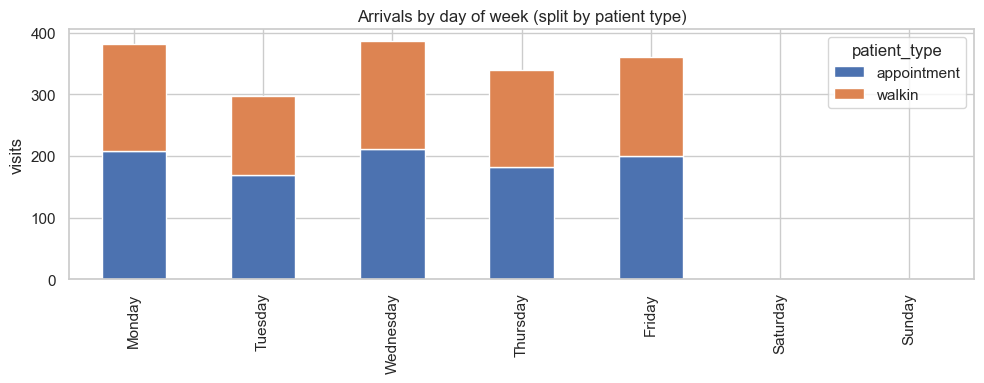

patient_type,appointment,walkin
dow,,
Monday,208.0,173.0
Tuesday,169.0,129.0
Wednesday,212.0,174.0
Thursday,182.0,158.0
Friday,200.0,160.0
Saturday,NaN,NaN
Sunday,NaN,NaN


In [7]:
arrivals = df.dropna(subset=["MUAYENE_KABUL_ZAMANI"]).copy()
arrivals["dow"] = arrivals["MUAYENE_KABUL_ZAMANI"].dt.day_name()
arrivals["hour"] = arrivals["MUAYENE_KABUL_ZAMANI"].dt.hour

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = (
    arrivals.groupby(["dow", "patient_type"]).size().unstack(fill_value=0).reindex(dow_order)
)

fig, ax = plt.subplots(figsize=(10, 4))
dow_counts.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Arrivals by day of week (split by patient type)")
ax.set_ylabel("visits")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(OUT_DIR / "arrivals_by_dow.png", dpi=150)
plt.show()
dow_counts

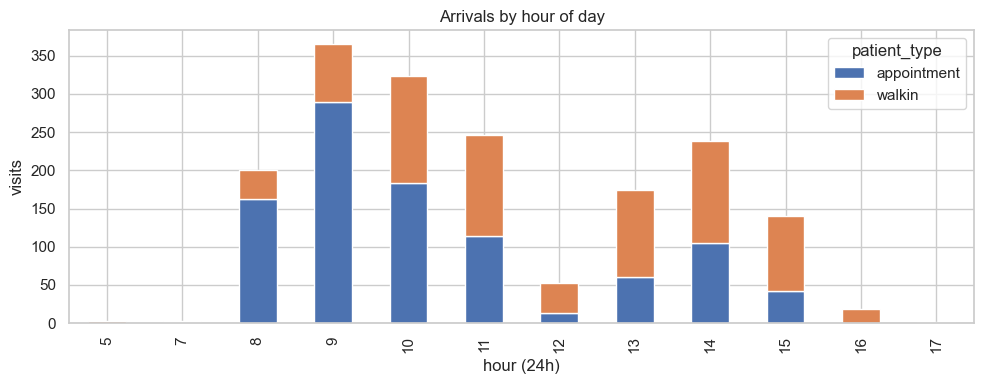

patient_type,appointment,walkin
hour,,
5,0,3
7,1,2
8,163,38
9,289,76
10,184,139
11,114,132
12,13,39
13,60,114
14,105,133


In [8]:
hour_counts = (
    arrivals.groupby(["hour", "patient_type"]).size().unstack(fill_value=0).sort_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
hour_counts.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Arrivals by hour of day")
ax.set_ylabel("visits")
ax.set_xlabel("hour (24h)")
fig.tight_layout()
fig.savefig(OUT_DIR / "arrivals_by_hour.png", dpi=150)
plt.show()
hour_counts

In [9]:
wed_check = (
    arrivals.assign(is_wed=arrivals["dow"] == "Wednesday")
    .groupby("is_wed")
    .agg(
        visits=("patient_type", "size"),
        walkin_share=("patient_type", lambda s: (s == "walkin").mean()),
        avg_total_minutes=("total_system_time", "mean"),
    )
    .rename(index={True: "Wednesday", False: "Other days"})
)
wed_check

,visits,walkin_share,avg_total_minutes
is_wed,,,
Other days,1379,0.449601,36.252342
Wednesday,386,0.450777,33.374802


In [10]:
ia_walkin = dp.inter_arrival_times(
    df[df["patient_type"] == "walkin"],
    time_column="MUAYENE_KABUL_ZAMANI",
    group_columns=("department",),
)
ia_appt = dp.inter_arrival_times(
    df[df["patient_type"] == "appointment"],
    time_column="RANDEVU_BASLAMA_SAATI",
    group_columns=("department",),
)
ia_walkin["patient_type"] = "walkin"
ia_appt["patient_type"] = "appointment"
inter_arrivals = pd.concat([ia_walkin, ia_appt], ignore_index=True)
inter_arrivals.groupby("patient_type")["inter_arrival_minutes"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
patient_type,,,,,,,,
appointment,790.0,10.55,18.00,0.50,3.00,6.0,10.00,147.0
walkin,762.0,11.62,19.85,0.02,1.88,5.1,12.11,172.2


## 4. Routing probabilities

Per-department probability that a patient is sent to the X-ray room (measured as the share of visits with a non-null `TETKIK_ISTEK_SAATI`). This populates `routing.xray_probability` in `config.yml`.

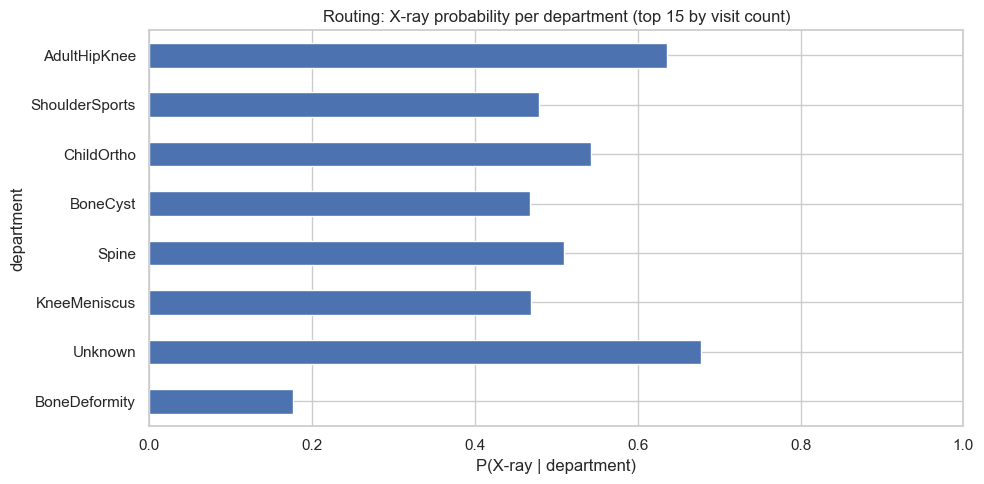

,visits,xray_visits,xray_probability
department,,,
AdultHipKnee,811,516,0.636
ShoulderSports,313,150,0.479
ChildOrtho,236,128,0.542
BoneCyst,203,95,0.468
Spine,167,85,0.509
KneeMeniscus,64,30,0.469
Unknown,59,40,0.678
BoneDeformity,17,3,0.176


In [11]:
routing = dp.compute_routing_probabilities(df)
routing.to_csv(OUT_DIR / "routing_probs.csv")

fig, ax = plt.subplots(figsize=(10, 5))
routing.head(15)["xray_probability"].plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("P(X-ray | department)")
ax.set_title("Routing: X-ray probability per department (top 15 by visit count)")
ax.set_xlim(0, 1)
fig.tight_layout()
fig.savefig(OUT_DIR / "routing_probabilities.png", dpi=150)
plt.show()
routing.round(3)

## 5. Service time distributions

Empirical view of the three service times before we commit to a parametric fit. Each plot shows both a histogram (shape) and an empirical CDF (tail behaviour).

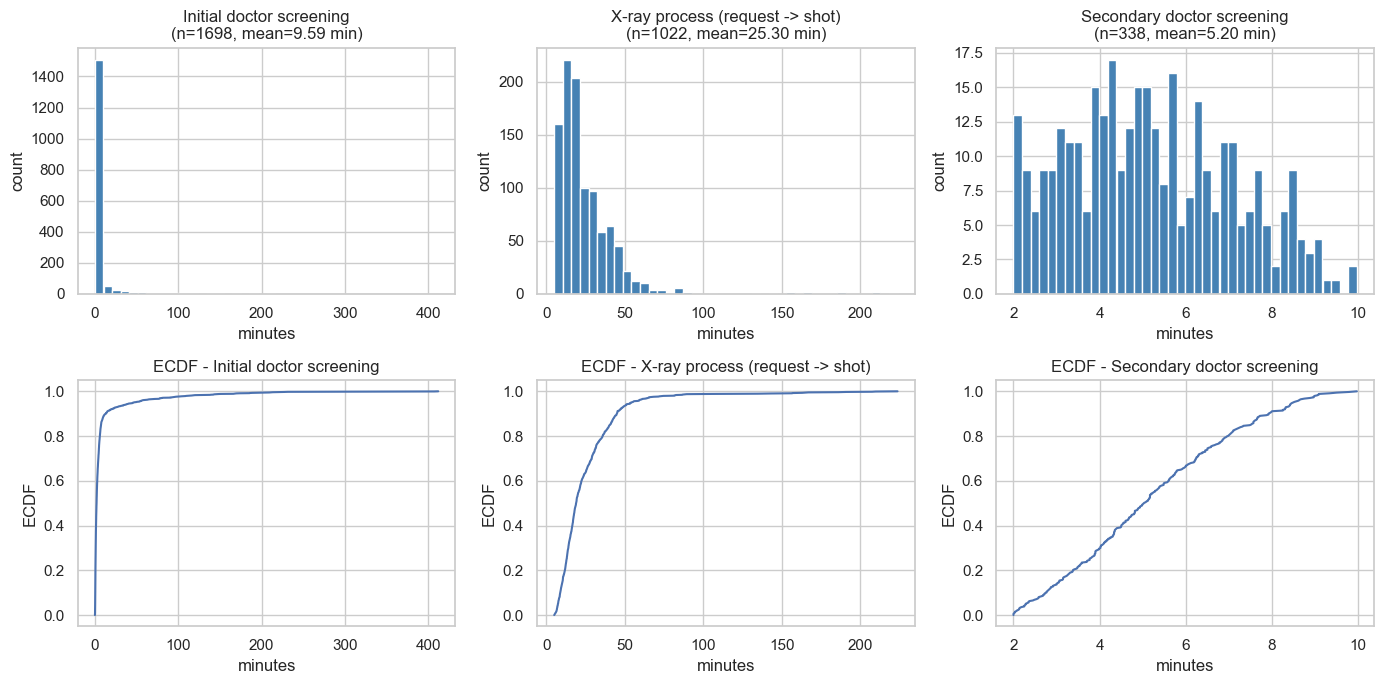

In [12]:
service_vars = {
    "initial_screening_time": "Initial doctor screening",
    "xray_wait_time": "X-ray process (request -> shot)",
    "secondary_screening_time": "Secondary doctor screening",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax_hist, ax_ecdf, (col, title) in zip(axes[0], axes[1], service_vars.items()):
    samples = df[col].dropna().to_numpy()
    ax_hist.hist(samples, bins=40, color="steelblue", edgecolor="white")
    ax_hist.set_title(f"{title}\n(n={len(samples)}, mean={samples.mean():.2f} min)")
    ax_hist.set_xlabel("minutes")
    ax_hist.set_ylabel("count")
    sorted_s = np.sort(samples)
    ax_ecdf.plot(sorted_s, np.linspace(0, 1, len(sorted_s)))
    ax_ecdf.set_xlabel("minutes")
    ax_ecdf.set_ylabel("ECDF")
    ax_ecdf.set_title(f"ECDF - {title}")
fig.tight_layout()
fig.savefig(OUT_DIR / "service_time_distributions.png", dpi=150)
plt.show()

## 6. Distribution fitting (full goodness-of-fit)

**IQR (Tukey) pre-filter (service times only):** before fitting, keep only positive samples inside `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]`. Dropped values are not used in K-S or MLE, but we report *n* before/after in `iqr_filter` inside `config.yml` for transparency in Section 1.4.

For every target variable we:

- Fit six candidate distributions (`expon`, `lognorm`, `gamma`, `weibull_min`, `triang`, `norm`).
- Run a Kolmogorov-Smirnov test and a binned Chi-square test.
- Rank candidates by *accepted at alpha=0.05 first*, then highest K-S p-value, then lowest AIC.

With 300-1700 samples K-S will often reject every theoretical distribution because small shape mismatches become detectable - we therefore also inspect Q-Q plots and AIC to pick the closest-to-reality candidate for the SimPy parameters.

In [13]:
import re

def _safe_slug(label: str) -> str:
    slug = re.sub(r"[^a-z0-9]+", "_", label.lower()).strip("_")
    return slug or "var"


def fit_and_report(samples: np.ndarray, label: str):
    """Return (fit_table, winner_dict) and save a ranked GoF CSV."""
    table = dp.fit_distributions(samples)
    table.to_csv(OUT_DIR / f"gof_{_safe_slug(label)}.csv", index=False)
    winner = dp.pick_winner(table)
    display_cols = ["candidate", "params", "ks_p", "chi2_p", "aic", "is_accepted"]
    print(f"=== {label} (n={len(samples)}) ===")
    print(f"Winner: {winner['dist']} (K-S p={winner['ks_p']:.4g}, AIC={winner['aic']:.1f})")
    return table[display_cols].round(4), winner


service_fits = {}
iqr_service_report = []
for col, title in service_vars.items():
    raw_samples = df[col].dropna().to_numpy()
    samples, iqr_meta = dp.apply_iqr_filter(raw_samples)
    iqr_service_report.append({"variable": col, **iqr_meta})
    print(f"{title}: raw n={iqr_meta['n_before']}, after IQR n={iqr_meta['n_after']}, dropped {iqr_meta['n_before'] - iqr_meta['n_after']}")
    table, winner = fit_and_report(samples, title)
    service_fits[col] = {"table": table, "winner": winner, "n_raw": len(raw_samples), "iqr": iqr_meta}
    display(table)

pd.DataFrame(iqr_service_report).to_csv(OUT_DIR / "iqr_service_times.csv", index=False)

xray_room_samples = dp.xray_samples_by_room(df)
xray_room_fits = {}
for room, raw_arr in xray_room_samples.items():
    samples, iqr_meta = dp.apply_iqr_filter(raw_arr)
    print(f"xray {room}: raw n={iqr_meta['n_before']}, after IQR n={iqr_meta['n_after']}")
    table, winner = fit_and_report(samples, f"xray {room} room")
    xray_room_fits[room] = {"table": table, "winner": winner, "n_raw": len(raw_arr), "iqr": iqr_meta}
    display(table)

Initial doctor screening: raw n=1698, after IQR n=1515, dropped 183
=== Initial doctor screening (n=1515) ===
Winner: lognorm (K-S p=0.00176, AIC=5760.8)


,candidate,params,ks_p,chi2_p,aic,is_accepted
0,lognorm,"(0.992806755944398, -0.03425225017121118, 1.6283492475970476)",0.0018,0.0,5760.8368,False
1,expon,"(0.03333333333333333, 2.4591419141914197)",0.0002,0.0,5760.4318,False
2,weibull_min,"(1.0752087769294656, 0.03317305962587529, 2.5319339451772405)",0.0000,0.0,5749.8605,False
3,gamma,"(1.1563614785550584, 0.03293995077754838, 2.126952924290145)",0.0000,0.0,5743.5902,False
4,norm,"(2.492475247524753, 2.3006784280334855)",0.0000,0.0,6827.9920,False
5,triang,"(0.01834870803021431, -0.0031256571662962567, 11.070282664941162)",0.0000,0.0,6131.7542,False


X-ray process (request -> shot): raw n=1022, after IQR n=983, dropped 39
=== X-ray process (request -> shot) (n=983) ===
Winner: gamma (K-S p=0.1486, AIC=7414.4)


,candidate,params,ks_p,chi2_p,aic,is_accepted
0,gamma,"(1.7571833935940355, 4.896505999999317, 9.82754312120883)",0.1486,0.0003,7414.3621,True
1,weibull_min,"(1.3946785164512736, 5.02832734258909, 18.799574747796395)",0.0394,0.0000,7407.8710,False
2,lognorm,"(0.62349317828286, 1.5533206545404754, 17.142311664497306)",0.0190,0.0000,7453.3473,False
3,triang,"(0.04614120151256541, 4.753457018918598, 55.551437238497655)",0.0000,0.0000,7410.3510,False
4,expon,"(5.066666666666666, 17.098643608002714)",0.0000,0.0000,7551.4723,False
5,norm,"(22.16531027466938, 12.362994031476498)",0.0000,0.0000,7737.5484,False


Secondary doctor screening: raw n=338, after IQR n=338, dropped 0
=== Secondary doctor screening (n=338) ===
Winner: triang (K-S p=0.7132, AIC=1360.9)


...

=== xray standing room (n=554) ===
Winner: gamma (K-S p=0.7004, AIC=3997.7)


,candidate,params,ks_p,chi2_p,aic,is_accepted
0,gamma,"(1.885445370047164, 5.030401727121693, 7.906828551475945)",0.7004,0.0560,3997.6887,True
1,weibull_min,"(1.4328076232123546, 5.272547366146239, 16.143539544782335)",0.5079,0.2043,3992.0515,True
2,lognorm,"(0.5636116537189526, 1.2591437557056608, 16.036243433395356)",0.4863,0.0338,4017.4033,True
3,triang,"(0.04411272622834885, 5.055250110446319, 45.9750104100094)",0.0000,0.0000,3992.1438,False
4,norm,"(19.938327316486163, 10.302401937892716)",0.0000,0.0000,4160.4577,False
5,expon,"(5.35, 14.588327316486163)",0.0000,0.0000,4081.6857,False


xray laying: raw n=435, after IQR n=428


=== xray laying room (n=428) ===
Winner: weibull_min (K-S p=0.1474, AIC=3411.2)


,candidate,params,ks_p,chi2_p,aic,is_accepted
0,weibull_min,"(1.3610686621911312, 4.9616412112925925, 22.878530248701065)",0.1474,0.0019,3411.2303,True
1,gamma,"(1.6590371319939172, 4.786104378602944, 12.744615331129395)",0.1239,0.0008,3416.9733,True
2,lognorm,"(0.6426274990679022, 0.7114722967596195, 20.789766638507036)",0.0298,0.0000,3439.5952,False
3,triang,"(0.04974113657899168, 4.409846866796977, 68.49099212848849)",0.0001,0.0007,3407.6440,False
4,expon,"(5.066666666666666, 20.86320093457944)",0.0000,0.0000,3460.5168,False
5,norm,"(25.929867601246105, 15.195102756343067)",0.0000,0.0000,3547.7644,False


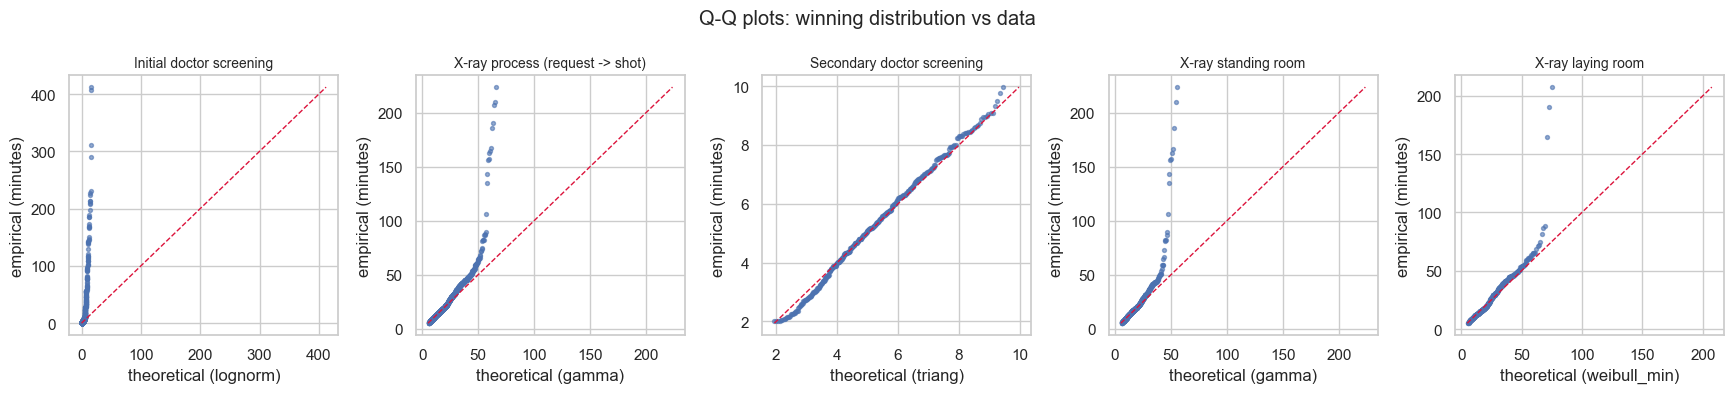

In [14]:
qq_panels: list[tuple[np.ndarray, dict, str]] = []
for col, title in service_vars.items():
    emp, _ = dp.apply_iqr_filter(df[col].dropna().to_numpy())
    qq_panels.append((emp, service_fits[col]["winner"], title))
for room, fit in xray_room_fits.items():
    emp, _ = dp.apply_iqr_filter(xray_room_samples[room])
    qq_panels.append((emp, fit["winner"], f"X-ray {room} room"))

ncols = len(qq_panels)
fig, axes = plt.subplots(1, ncols, figsize=(3.5 * ncols, 4))
for ax, (samples, winner, title) in zip(axes, qq_panels):
    dist = getattr(stats, winner["dist"])
    theoretical = dist.ppf(np.linspace(0.01, 0.99, len(samples)), *winner["params"])
    empirical = np.sort(samples)
    ax.scatter(theoretical, empirical, s=8, alpha=0.6)
    lims = [min(theoretical.min(), empirical.min()), max(theoretical.max(), empirical.max())]
    ax.plot(lims, lims, color="crimson", linestyle="--", linewidth=1)
    ax.set_xlabel(f"theoretical ({winner['dist']})")
    ax.set_ylabel("empirical (minutes)")
    ax.set_title(title, fontsize=10)
fig.suptitle("Q-Q plots: winning distribution vs data")
fig.tight_layout()
fig.savefig(OUT_DIR / "qq_service_times.png", dpi=150)
plt.show()

### 6b. Walk-in inter-arrival; appointments = deterministic schedule

Walk-ins: the data only records the time the doctor accepted the patient, not the instant they crossed the front door. We therefore jitter `MUAYENE_KABUL_ZAMANI` by a `Triangular(-10, 0, +5)` minute offset and fit the resulting inter-arrival series. This assumption is captured in `config.assumptions.walkin_jitter` and should be copied verbatim into **Section 1.4 Modelling Assumptions**.

**Appointments** are *not* modelled with a parametric inter-arrival distribution. They follow the polyclinic booking grid defined in `config['arrivals']['appointment']` (named schedules + per-department `schedule_1` / `schedule_2` / `schedule_3`). The SimPy driver uses `simulation.appointment_generator` to release patients at those exact slot times, with `yield env.timeout` covering lunch and overnight gaps.

In [15]:
walkin_df = df[df["patient_type"] == "walkin"].copy()
jitter = stats.triang(c=(0 - (-10)) / (5 - (-10)), loc=-10, scale=15).rvs(size=len(walkin_df), random_state=RNG)
walkin_df["MUAYENE_KABUL_ZAMANI_JITTERED"] = walkin_df["MUAYENE_KABUL_ZAMANI"] + pd.to_timedelta(jitter, unit="m")

ia_walkin_j = dp.inter_arrival_times(
    walkin_df,
    time_column="MUAYENE_KABUL_ZAMANI_JITTERED",
    group_columns=("department",),
)
walkin_samples = ia_walkin_j["inter_arrival_minutes"].to_numpy()
walkin_table, walkin_winner = fit_and_report(walkin_samples, "walkin inter-arrival")
display(walkin_table)

=== walkin inter-arrival (n=763) ===
Winner: lognorm (K-S p=0.5287, AIC=5089.7)


,candidate,params,ks_p,chi2_p,aic,is_accepted
0,lognorm,"(1.3664762129900294, -0.12967309408066102, 4.954004707221484)",0.5287,0.462,5089.6708,True
1,weibull_min,"(0.6979440241738416, 0.0006199688333333333, 10.830396376545462)",0.0000,0.000,5107.6003,False
2,expon,"(0.0006199688333333334, 11.62200666815557)",0.0000,0.000,5273.1261,False
3,norm,"(11.622626636988905, 19.66800853458086)",0.0000,0.000,6715.2441,False
4,triang,"(8.616256719248653e-05, -0.014684814672853201, 177.61522461469633)",0.0000,0.000,6982.7630,False
5,gamma,"(0.11529103876110247, 0.0006199688333333333, 3.2993169379184097)",0.0000,0.000,10769.3667,False


In [16]:
from simulation import day_slot_times

for sid in ("schedule_1", "schedule_2", "schedule_3"):
    w = APPOINTMENT_SCHEDULES[sid]["windows"]
    n0 = len(day_slot_times(0, w))
    print(f"{sid} slots on first day (from 08:00 anchor in simulation.py): {n0}")

appt_mode = (
    pd.Series(ia_appt["inter_arrival_minutes"].round(0).astype(int))
    .value_counts()
    .head(5)
)
print("(Exploratory) top scheduled inter-arrival *gaps* in the historical data — not used in SimPy, appointments use the YAML grid above.")
print(appt_mode)

schedule_1 slots on first day (from 08:00 anchor in simulation.py): 70
schedule_2 slots on first day (from 08:00 anchor in simulation.py): 53
schedule_3 slots on first day (from 08:00 anchor in simulation.py): 35
(Exploratory) top scheduled inter-arrival *gaps* in the historical data — not used in SimPy, appointments use the YAML grid above.
inter_arrival_minutes
2    122
7     87
8     78
4     76
6     63
Name: count, dtype: int64


## 7. Emit `config.yml`

All the fitted parameters get written to `config.yml` so `simulation.py` (built in the next milestone) can consume them without touching the data. The file is human-readable and can be tweaked manually for what-if scenarios in the Streamlit dashboard.

In [17]:
def winner_block(winner: dict, *, n_raw: int | None = None, iqr_meta: dict | None = None) -> dict:
    out = {
        "dist": winner["dist"],
        "params": [float(x) for x in winner["params"]],
        "ks_p": float(winner["ks_p"]),
        "aic": float(winner["aic"]),
        "n": int(winner["n"]),
    }
    if n_raw is not None:
        out["n_raw"] = int(n_raw)
    if iqr_meta is not None:
        out["iqr_filter"] = {
            k: (int(v) if k in ("n_before", "n_after", "n_in", "n_outliers") else v)
            for k, v in iqr_meta.items()
        }
    return out


departments = routing.index.tolist()

appointment_arrivals = {
    "mode": "deterministic_schedule",
    "sim_time_zero_is": "08:00_first_day",
    "day_length_minutes": 1440,
    "schedules": APPOINTMENT_SCHEDULES,
    "department_schedules": {dept: "schedule_1" for dept in departments},
}

config = {
    "resources": {
        "doctors_per_department": {dept: 1 for dept in departments},
        "xray_rooms": {"standing": 1, "laying": 1},
    },
    "routing": {
        "xray_probability": {
            dept: float(round(p, 4))
            for dept, p in routing["xray_probability"].items()
        }
    },
    "service_times": {
        "initial_screening": winner_block(
            service_fits["initial_screening_time"]["winner"],
            n_raw=service_fits["initial_screening_time"]["n_raw"],
            iqr_meta=service_fits["initial_screening_time"]["iqr"],
        ),
        "xray_process": {
            "pooled": winner_block(
                service_fits["xray_wait_time"]["winner"],
                n_raw=service_fits["xray_wait_time"]["n_raw"],
                iqr_meta=service_fits["xray_wait_time"]["iqr"],
            ),
            "standing": winner_block(
                xray_room_fits["standing"]["winner"],
                n_raw=xray_room_fits["standing"]["n_raw"],
                iqr_meta=xray_room_fits["standing"]["iqr"],
            ),
            "laying": winner_block(
                xray_room_fits["laying"]["winner"],
                n_raw=xray_room_fits["laying"]["n_raw"],
                iqr_meta=xray_room_fits["laying"]["iqr"],
            ),
        },
        "secondary_screening": winner_block(
            service_fits["secondary_screening_time"]["winner"],
            n_raw=service_fits["secondary_screening_time"]["n_raw"],
            iqr_meta=service_fits["secondary_screening_time"]["iqr"],
        ),
    },
    "arrivals": {
        "walkin": winner_block(walkin_winner),
        "appointment": appointment_arrivals,
    },
    "assumptions": {
        "walkin_jitter": {
            "dist": "triang",
            "min_minutes": -10,
            "mode_minutes": 0,
            "max_minutes": 5,
            "note": "Patient crossed the front door somewhere in this window relative to MUAYENE_KABUL_ZAMANI.",
        },
        "follow_up_day": "Wednesday",
        "late_arrival_cutoff": "16:00",
        "scoliosis_room_id": 160,
        "appointment_deviation_hours": 1.0,
    },
}

with open("config.yml", "w", encoding="utf-8") as fh:
    yaml.safe_dump(config, fh, sort_keys=False, allow_unicode=True)
print("Wrote config.yml")
print(yaml.safe_dump(config["service_times"], sort_keys=False, allow_unicode=True))

Wrote config.yml
initial_screening:
  dist: lognorm
  params:
  - 0.992806755944398
  - -0.03425225017121118
  - 1.6283492475970476
  ks_p: 0.0017598150584924534
  aic: 5760.836771355984
  n: 1515
  n_raw: 1698
  iqr_filter:
    n_in: 1698
    n_outliers: 183
    q1: 0.8166666666666667
    q3: 4.929166666666667
    iqr: 4.112500000000001
    lower: 0.0
    upper: 11.097916666666668
    factor: 1.5
    n_before: 1698
    n_after: 1515
xray_process:
  pooled:
    dist: gamma
    params:
    - 1.7571833935940355
    - 4.896505999999317
    - 9.82754312120883
    ks_p: 0.14863486785189695
    aic: 7414.362077540399
    n: 983
    n_raw: 1022
    iqr_filter:
      n_in: 1022
      n_outliers: 39
      q1: 12.954166666666666
      q3: 31.641666666666666
      iqr: 18.6875
      lower: 0.0
      upper: 59.672916666666666
      factor: 1.5
      n_before: 1022
      n_after: 983
  standing:
    dist: gamma
    params:
    - 1.885445370047164
    - 5.030401727121693
    - 7.906828551475945
    

## 8. QA sanity check

Re-read `config.yml`, draw 10 000 samples from each fitted distribution, and compare the simulated mean/std/quantiles against the empirical values. If any row's ratio is wildly off (> 20% deviation in mean or std) we flag it for manual review before using the config in `simulation.py`.

In [18]:
with open("config.yml", "r", encoding="utf-8") as fh:
    reloaded = yaml.safe_load(fh)

def _emp_iqr(col: str) -> np.ndarray:
    return dp.apply_iqr_filter(df[col].dropna().to_numpy())[0]


qa_specs = [
    ("service_times.initial_screening", reloaded["service_times"]["initial_screening"], _emp_iqr("initial_screening_time")),
    ("service_times.xray_process.pooled", reloaded["service_times"]["xray_process"]["pooled"], dp.apply_iqr_filter(df["xray_wait_time"].dropna().to_numpy())[0]),
    ("service_times.xray_process.standing", reloaded["service_times"]["xray_process"]["standing"], dp.apply_iqr_filter(xray_room_samples["standing"])[0]),
    ("service_times.xray_process.laying", reloaded["service_times"]["xray_process"]["laying"], dp.apply_iqr_filter(xray_room_samples["laying"])[0]),
    ("service_times.secondary_screening", reloaded["service_times"]["secondary_screening"], _emp_iqr("secondary_screening_time")),
    ("arrivals.walkin", reloaded["arrivals"]["walkin"], walkin_samples),
]

rows = []
for name, spec, empirical in qa_specs:
    dist = getattr(stats, spec["dist"])
    sim = dist.rvs(*spec["params"], size=10_000, random_state=RNG)
    rows.append(
        {
            "variable": name,
            "dist": spec["dist"],
            "n_empirical": len(empirical),
            "mean_emp": float(np.mean(empirical)),
            "mean_sim": float(np.mean(sim)),
            "std_emp": float(np.std(empirical)),
            "std_sim": float(np.std(sim)),
            "p50_emp": float(np.median(empirical)),
            "p50_sim": float(np.median(sim)),
            "mean_pct_diff": float(abs(np.mean(sim) - np.mean(empirical)) / max(np.mean(empirical), 1e-9) * 100),
        }
    )

qa = pd.DataFrame(rows)
qa["flag"] = qa["mean_pct_diff"].apply(lambda x: "OK" if x < 20 else "REVIEW")
qa.to_csv(OUT_DIR / "qa_sanity_check.csv", index=False)
qa.round(3)

,variable,dist,n_empirical,mean_emp,mean_sim,std_emp,std_sim,p50_emp,p50_sim,mean_pct_diff,flag
0,service_times.initial_screening,lognorm,1515,2.492,2.638,2.301,3.296,1.650,1.629,5.858,OK
1,service_times.xray_process.pooled,gamma,983,22.165,22.131,12.363,13.032,18.383,19.026,0.156,OK
2,service_times.xray_process.standing,gamma,554,19.938,19.932,10.302,10.840,17.583,17.408,0.032,OK
3,service_times.xray_process.laying,weibull_min,428,25.930,25.729,15.195,15.485,21.567,22.303,0.776,OK
4,service_times.secondary_screening,triang,338,5.195,5.202,1.898,1.843,5.025,4.991,0.125,OK
5,arrivals.walkin,lognorm,763,11.623,12.645,19.668,31.766,5.070,4.908,8.796,OK


## Outputs summary

The `outputs/` folder now contains everything that needs to go into the report:

- `cleaning_audit.csv` - Section 1.3 data-quality table
- `missing_value_heatmap.png`, `arrivals_by_dow.png`, `arrivals_by_hour.png` - Section 1.3 figures
- `service_time_distributions.png`, `qq_service_times.png` - Section 1.3 / 1.4 figures
- `routing_probs.csv`, `routing_probabilities.png` - Section 1.4 / 2.1 routing probabilities
- `gof_*.csv` - one goodness-of-fit table per fitted variable
- `qa_sanity_check.csv` - proof that `config.yml` reproduces the empirical moments

Resolved open items:

1. `DOKTOR_ADI -> department` mapping comes from `Baltalimani_Data_2025.csv` (first-specialty rule). Produces 8 departments plus `Unknown` for the one unlisted doctor.
2. Late-arrival cutoff fixed at 16:00 per the clinic's end-of-day policy.
3. `config.service_times.xray_process` now exposes **three** distributions: `pooled`, `standing`, and `laying`. The simulation can choose the split based on the target patient's modality.